<a href="https://colab.research.google.com/github/448012877-gif/rby/blob/main/SEM0514.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 第一步：挂载 Google Drive 并解压数据集
我们将访问存储在 Google Drive 中的数据集，并将其解压到本地环境以便训练模型。

In [15]:
from google.colab import drive
import os

# 挂载 Google Drive
drive.mount('/content/drive')

# 定义数据集在 Drive 中的路径和解压的目标路径
zip_path = '/content/drive/MyDrive/SEM_Segmentation_Project/data/SEM_dataset.zip'
extract_path = '/content/dataset'

# 检查文件是否存在并执行解压
if os.path.exists(zip_path):
    # 使用 -q 参数进行静默解压，-d 指定目标目录
    !unzip -q "{zip_path}" -d "{extract_path}"
    print(f"数据集已成功解压至: {extract_path}")
else:
    print(f"错误：在路径 {zip_path} 未找到压缩文件，请检查路径是否正确。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/dataset/images/sample_001.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: 数据集已成功解压至: /content/dataset


In [4]:
# 查看解压后的文件结构，确认 images 和 masks 文件夹
print("解压后的目录结构：")
!ls -F /content/dataset

解压后的目录结构：
images/  masks/


### 第二步：图像切片处理
由于原始图片分辨率较高，我们将图片切割成 256x256 的小块（Patches），以适配模型训练并增加训练样本量。

In [1]:
import shutil
import os

# 定义需要清理的根目录
patches_dir = '/content/patches'

if os.path.exists(patches_dir):
    # 递归删除整个文件夹及其内容
    shutil.rmtree(patches_dir)
    print(f"已成功清理旧文件夹: {patches_dir}")
else:
    print("文件夹不存在，无需清理。")

# 重新创建基础结构
os.makedirs(os.path.join(patches_dir, 'images'), exist_ok=True)
os.makedirs(os.path.join(patches_dir, 'masks'), exist_ok=True)
print("已重新创建空的 /content/patches/images 和 /content/patches/masks 目录。")

已成功清理旧文件夹: /content/patches
已重新创建空的 /content/patches/images 和 /content/patches/masks 目录。


In [2]:
!pip install patchify
import cv2
import numpy as np
from patchify import patchify
import glob
import os
import shutil

# 定义切片大小
patch_size = 256

# 每次重新生成前清空旧切片，防止文件名冲突
if os.path.exists('/content/patches'):
    shutil.rmtree('/content/patches')

os.makedirs('/content/patches/images', exist_ok=True)
os.makedirs('/content/patches/masks', exist_ok=True)

# 增强路径查找
def get_files(path, extensions=['jpg', 'jpeg', 'png', 'tif', 'JPG', 'PNG', 'TIF']):
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(path, f'*.{ext}')))
    return sorted(files)

image_list = get_files('/content/dataset/images')
mask_list = get_files('/content/dataset/masks')

if len(image_list) == 0:
    print("警告：未找到图片。")
else:
    print(f"开始处理 {len(image_list)} 张图片 (保存为顺序编号的 TIF)... ")

    # 初始化全局计数器
    counter = 0

    for i in range(len(image_list)):
        image = cv2.imread(image_list[i], 1)
        mask = cv2.imread(mask_list[i], 0)

        if image is None or mask is None: continue

        h, w = image.shape[:2]
        new_h, new_w = (h // patch_size) * patch_size, (w // patch_size) * patch_size
        image = image[:new_h, :new_w]
        mask = mask[:new_h, :new_w]

        patches_img = patchify(image, (patch_size, patch_size, 3), step=patch_size)
        patches_mask = patchify(mask, (patch_size, patch_size), step=patch_size)

        for j in range(patches_img.shape[0]):
            for k in range(patches_img.shape[1]):
                single_patch_img = patches_img[j, k, 0, :, :, :]
                single_patch_mask = patches_mask[j, k, :, :]

                # 使用 5 位补零的顺序文件名 (e.g., 00001.tif)
                file_name = str(counter).zfill(5)

                cv2.imwrite(f'/content/patches/images/{file_name}.tif', single_patch_img)
                cv2.imwrite(f'/content/patches/masks/{file_name}.png', single_patch_mask)

                counter += 1

    print(f"切片处理完成！所有文件已重命名为 00000-{counter-1} 序列。")
    print(f"生成的图像切片总数: {len(os.listdir('/content/patches/images/'))}")

开始处理 112 张图片 (保存为顺序编号的 TIF)... 
切片处理完成！所有文件已重命名为 00000-2015 序列。
生成的图像切片总数: 2016


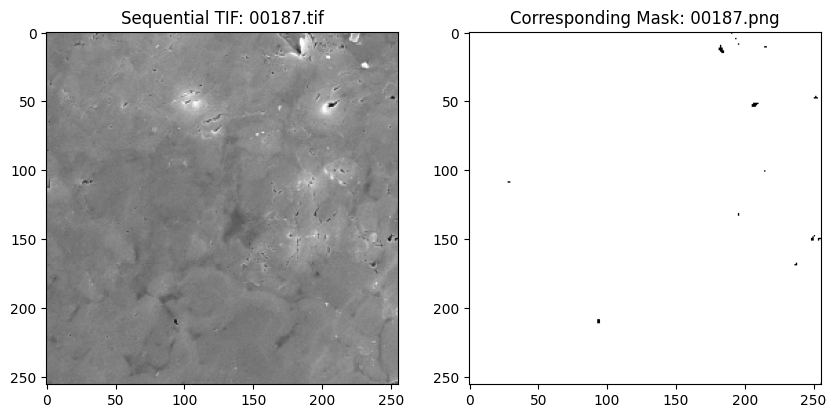

In [4]:
import matplotlib.pyplot as plt
import random

# 检查重命名后的文件
patch_images = sorted([f for f in os.listdir('/content/patches/images') if f.endswith('.tif')])
patch_masks = sorted([f for f in os.listdir('/content/patches/masks') if f.endswith('.png')])

if len(patch_images) > 0:
    idx = random.randint(0, len(patch_images) - 1)

    img_patch = cv2.imread(os.path.join('/content/patches/images', patch_images[idx]))
    mask_patch = cv2.imread(os.path.join('/content/patches/masks', patch_masks[idx]), 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Sequential TIF: {patch_images[idx]}")
    plt.imshow(cv2.cvtColor(img_patch, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 2, 2)
    plt.title(f"Corresponding Mask: {patch_masks[idx]}")
    plt.imshow(mask_patch, cmap='gray')
    plt.show()
else:
    print("请先重新运行切片单元格。")

In [5]:
import torch

# 检查 GPU 是否可用
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU 已就绪！设备名称: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("当前使用的是 CPU。如果需要加速，请按照上述步骤切换至 GPU 运行时。")

GPU 已就绪！设备名称: Tesla T4


### 第三步：构建 PyTorch 数据集与数据增强
我们将创建一个自定义的 `RockDataset` 类，并使用 `torchvision.transforms` 进行数据增强。最后将数据集按 8:1:1 逻辑划分为训练、验证和测试集。

In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import random

class RockDataset(Dataset):
    def __init__(self, img_dir, mask_dir, is_train=True):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.is_train = is_train
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.tif')])

        # 固定的归一化处理
        self.img_norm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        self.mask_to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = img_name.replace('.tif', '.png')

        image = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, mask_name)).convert("L")

        if self.is_train:
            # 随机空间变换（图像和掩码必须同步）
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                image = TF.rotate(image, angle)
                mask = TF.rotate(mask, angle)

        image = self.img_norm(image)
        mask = self.mask_to_tensor(mask)

        return image, mask

# 重新实例化并划分数据集
full_dataset = RockDataset('/content/patches/images', '/content/patches/masks', is_train=True)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# 注意：划分后我们需要手动设置验证集/测试集不使用增强
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])
val_dataset.dataset.is_train = False
test_dataset.dataset.is_train = False

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("数据集已修复并重新加载。")

数据集已修复并重新加载。


### 第四步：定义 UNet 模型架构
下面是一个经典的 UNet 实现，包含编码器（下采样）和解码器（上采样+跳跃连接）。

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(卷积 => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up3(x)

        logits = self.outc(x)
        return logits

# 实例化模型（输入3通道，输出1通道用于二分类分割）
model = UNet(n_channels=3, n_classes=1).to(device)
print("UNet 模型已加载到 GPU。")

UNet 模型已加载到 GPU。


### 第五步：设置训练参数与训练循环
我们将定义损失函数、优化器，并编写训练和验证的逻辑代码。

In [16]:
import torch.optim as optim
from tqdm import tqdm

# 1. 定义超参数
LEARNING_RATE = 1e-4
EPOCHS = 20

# 2. 损失函数与优化器
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. 训练函数
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        # 修复点：DataLoader 出来的 masks 已经是 [B, 1, H, W]，无需再次 unsqueeze
        masks = masks.to(device).float()

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, masks)

        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(loader)

# 4. 验证函数
def validate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device).float()
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item()
    return running_loss / len(loader)

# 5. 执行训练过程
print("开始训练...")
for epoch in range(EPOCHS):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss = validate_model(model, val_loader, criterion, device)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("训练完成！")

开始训练...


Epoch [1/20] - Train Loss: 0.3151, Val Loss: 0.2487


Epoch [2/20] - Train Loss: 0.2111, Val Loss: 0.2174


Epoch [3/20] - Train Loss: 0.1737, Val Loss: 0.1585


Epoch [4/20] - Train Loss: 0.1463, Val Loss: 0.1325


...

Epoch [16/20] - Train Loss: 0.0382, Val Loss: 0.0399


Epoch [17/20] - Train Loss: 0.0355, Val Loss: 0.0373


Epoch [18/20] - Train Loss: 0.0334, Val Loss: 0.0358


Epoch [19/20] - Train Loss: 0.0317, Val Loss: 0.0348


Epoch [20/20] - Train Loss: 0.0304, Val Loss: 0.0328
训练完成！


### 第六步：在测试集上进行推理可视化
训练完成后，我们可以从测试集中抽取一张图片，查看模型的预测效果。

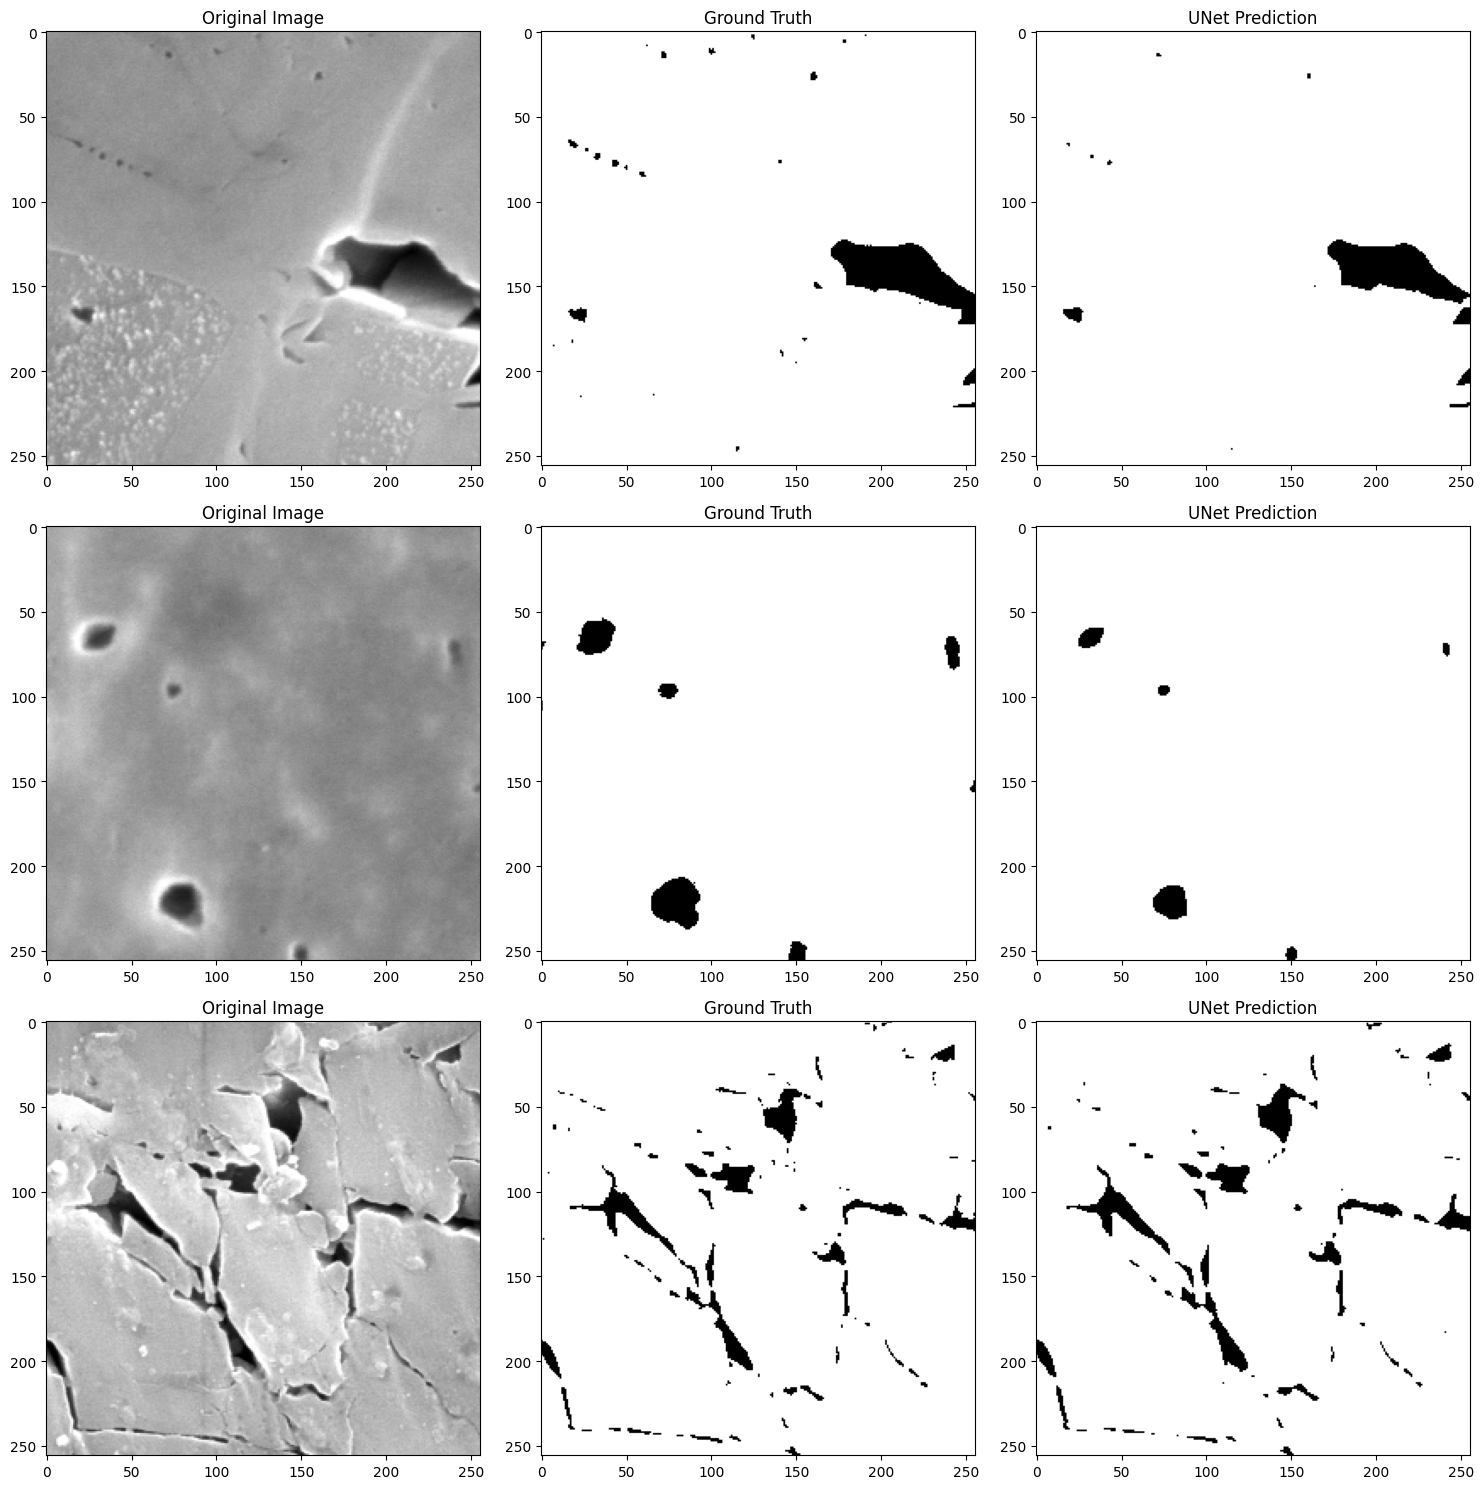

In [17]:
import matplotlib.pyplot as plt

def plot_predictions(model, dataset, device, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image, mask = dataset[idx]

        # 准备输入数据
        input_tensor = image.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            prediction = torch.sigmoid(output).squeeze().cpu().numpy()
            # 二值化处理：阈值设为 0.5
            pred_mask = (prediction > 0.5).astype(np.uint8)

        # 显示原图（需要反归一化以便正确显示颜色）
        img_display = image.permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i, 0].imshow(np.clip(img_display, 0, 1))
        axes[i, 0].set_title("Original Image")

        # 显示真实掩码
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth")

        # 显示预测结果
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title("UNet Prediction")

    plt.tight_layout()
    plt.show()

# 运行可视化
plot_predictions(model, test_dataset, device)

### 第七步：计算评价指标 (IoU)
IoU (Intersection over Union) 是衡量预测掩码与真实掩码重合度的核心指标。我们将遍历测试集计算平均 IoU。

In [18]:
def calculate_iou(pred, target, threshold=0.5):
    # 将模型输出进行 Sigmoid 并根据阈值二值化
    pred = (torch.sigmoid(pred) > threshold).float()

    # 计算交集和并集
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    # 避免除以 0
    if union == 0:
        return 1.0

    return (intersection / union).item()

def evaluate_metrics(model, loader, device):
    model.eval()
    total_iou = 0.0
    num_batches = len(loader)

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating IoU"):
            images = images.to(device)
            masks = masks.to(device).float()

            outputs = model(images)
            batch_iou = calculate_iou(outputs, masks)
            total_iou += batch_iou

    avg_iou = total_iou / num_batches
    return avg_iou

# 在测试集上运行评估
print("正在计算测试集 IoU...")
test_iou = evaluate_metrics(model, test_loader, device)
print(f"\n测试集平均 IoU: {test_iou:.4f}")

正在计算测试集 IoU...


Evaluating IoU: 100%|██████████| 13/13 [00:04<00:00,  2.74it/s]


测试集平均 IoU: 0.9924


### 第八步：全尺寸图像推理与拼接
此代码支持上传一张 1536x1020 的图片，自动进行切片、归一化、预测，并最后拼回原始尺寸。

In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from google.colab import files

def inference_full_image(model, image_path, device, patch_size=256):
    # 1. 加载图像
    img_raw = cv2.imread(image_path)
    h, w = img_raw.shape[:2]

    # 2. 计算填充 (Padding)
    # 1020 需要填充到 1024 (256*4)
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    img_padded = cv2.copyMakeBorder(img_raw, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

    new_h, new_w = img_padded.shape[:2]
    full_mask = np.zeros((new_h, new_w), dtype=np.uint8)

    # 3. 归一化预处理定义
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    model.eval()
    # 4. 循环切片推理
    for i in range(0, new_h, patch_size):
        for j in range(0, new_w, patch_size):
            # 提取切片
            patch = img_padded[i:i+patch_size, j:j+patch_size, :]
            # 转换为 PIL 再转 Tensor
            patch_pil = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
            input_tensor = transform(patch_pil).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                pred = torch.sigmoid(output).squeeze().cpu().numpy()
                # 二值化
                binary_mask = (pred > 0.5).astype(np.uint8) * 255

            # 填入大图
            full_mask[i:i+patch_size, j:j+patch_size] = binary_mask

    # 5. 裁剪回原始尺寸 1536x1020
    final_mask = full_mask[0:h, 0:w]
    return final_mask

# --- 运行部分 ---
print("请上传您的 .tif 图像文件：")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"正在处理: {filename}")
    result_mask = inference_full_image(model, filename, device)

    # 保存结果为 PNG
    output_name = filename.rsplit('.', 1)[0] + "_segmented.png"
    cv2.imwrite(output_name, result_mask)

    # 可视化对比
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original TIF")
    plt.imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB))
    plt.subplot(1, 2, 2)
    plt.title(f"Segmented PNG ({result_mask.shape[1]}x{result_mask.shape[0]})")
    plt.imshow(result_mask, cmap='gray')
    plt.show()

    print(f"预测完成！结果已保存为: {output_name}")

KeyboardInterrupt: 

### 第九步：下载生成的预测图像
使用此单元格可以方便地将推理得到的结果下载到本地。

In [22]:
from google.colab import files
import os

# 检查文件是否存在并提供下载
if 'output_name' in locals() and os.path.exists(output_name):
    print(f"正在准备下载文件: {output_name}")
    files.download(output_name)
else:
    print("未找到推理结果文件，请先运行上方的推理单元格。")

正在准备下载文件: sample_003_segmented.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 第十步：保存与加载模型 (Persistence)
将训练好的权重保存到 Google Drive，以便日后直接进行推理或继续训练。

In [23]:
# 定义保存路径（建议保存在您的项目文件夹中）
save_path = '/content/drive/MyDrive/SEM_Segmentation_Project/models/unet_rock_pore_v1.pth'

# 确保模型所在的文件夹存在
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# 保存模型权重 (state_dict)
torch.save(model.state_dict(), save_path)
print(f"模型已成功保存至: {save_path}")

模型已成功保存至: /content/drive/MyDrive/SEM_Segmentation_Project/models/unet_rock_pore_v1.pth


#### 下次使用时如何加载？
只需重新运行上面的 `UNet` 类定义代码，然后执行以下操作：

In [ ]:
# 1. 实例化一个结构完全相同的模型
# new_model = UNet(n_channels=3, n_classes=1).to(device)

# 2. 加载权重
# new_model.load_state_dict(torch.load(save_path))
# new_model.eval()
# print("模型权重加载成功！")

### 加载模型示例
运行以下代码将从您的 Google Drive 加载训练好的权重。

In [5]:
import torch
import torch.nn as nn
import os

# --- 必须先定义模型结构，才能加载权重 ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3)
        x = self.up1(x4); x = torch.cat([x, x3], dim=1); x = self.conv_up1(x)
        x = self.up2(x); x = torch.cat([x, x2], dim=1); x = self.conv_up2(x)
        x = self.up3(x); x = torch.cat([x, x1], dim=1); x = self.conv_up3(x)
        return self.outc(x)

# --- 加载逻辑 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
load_path = '/content/drive/MyDrive/SEM_Segmentation_Project/models/unet_rock_pore_v1.pth'

if os.path.exists(load_path):
    loaded_model = UNet(n_channels=3, n_classes=1).to(device)
    state_dict = torch.load(load_path, map_location=device)
    loaded_model.load_state_dict(state_dict)
    loaded_model.eval()
    print(f"成功从 {load_path} 加载模型权重！设备: {device}")
else:
    print(f"错误：未在 {load_path} 找到模型。请确认 Google Drive 已挂载。")

成功从 /content/drive/MyDrive/SEM_Segmentation_Project/models/unet_rock_pore_v1.pth 加载模型权重！设备: cuda


### 调试：检查 Google Drive 挂载与路径

In [4]:
from google.colab import drive
import os

# 1. 尝试重新挂载
drive.mount('/content/drive', force_remount=True)

# 2. 检查目标目录是否存在
target_dir = '/content/drive/MyDrive/SEM_Segmentation_Project/models/'

if os.path.exists(target_dir):
    print(f"目录 {target_dir} 存在，包含以下文件：")
    print(os.listdir(target_dir))
else:
    print(f"错误：找不到目录 {target_dir}。")
    # 尝试列出 MyDrive 下的内容协助排查
    print("您的 MyDrive 根目录下有以下文件夹：")
    print([d for d in os.listdir('/content/drive/MyDrive') if os.path.isdir(os.path.join('/content/drive/MyDrive', d))])

Mounted at /content/drive
目录 /content/drive/MyDrive/SEM_Segmentation_Project/models/ 存在，包含以下文件：
['unet_rock_pore_v1.pth']


### 针对 1280x960 (带水印) 图像的专项推理流程
此流程会自动裁剪底部 70 像素水印，完成 256x256 分块推理后再拼合，并恢复水印区域。

In [19]:
import cv2
import numpy as np
import torch
from google.colab import files
import matplotlib.pyplot as plt
import os

def process_sem_no_torchvision(model, image_path, device, patch_size=256, watermark_height=70):
    # 1. 读取图像
    img_raw = cv2.imread(image_path)
    if img_raw is None: raise ValueError(f"无法读取图像: {image_path}")
    h, w = img_raw.shape[:2]

    # 2. 裁剪水印
    img_main = img_raw[0:h-watermark_height, :, :]
    watermark_part = img_raw[h-watermark_height:h, :, :]
    h_main, w_main = img_main.shape[:2]

    # 3. Padding
    pad_h = (patch_size - h_main % patch_size) % patch_size
    pad_w = (patch_size - w_main % patch_size) % patch_size
    img_padded = cv2.copyMakeBorder(img_main, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

    new_h, new_w = img_padded.shape[:2]
    mask_padded = np.zeros((new_h, new_w), dtype=np.uint8)

    model.eval()
    with torch.no_grad():
        for i in range(0, new_h, patch_size):
            for j in range(0, new_w, patch_size):
                # 4. 手动预处理
                patch = img_padded[i:i+patch_size, j:j+patch_size, :]
                patch_rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)
                patch_float = patch_rgb.astype(np.float32) / 255.0
                patch_norm = (patch_float - 0.5) / 0.5
                input_tensor = torch.from_numpy(patch_norm.transpose(2, 0, 1)).unsqueeze(0).to(device)

                # 5. 推理
                output = model(input_tensor)
                pred = torch.sigmoid(output).squeeze().cpu().numpy()
                mask_padded[i:i+patch_size, j:j+patch_size] = (pred > 0.5).astype(np.uint8) * 255

    # 6. 拼回水印
    mask_main = mask_padded[0:h_main, 0:w_main]
    mask_main_bgr = cv2.cvtColor(mask_main, cv2.COLOR_GRAY2BGR)
    final_output = cv2.vconcat([mask_main_bgr, watermark_part])
    return final_output

# --- 执行逻辑：支持多文件批量上传 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'loaded_model' not in locals():
    print("请先运行上方的『加载模型』单元格！")
else:
    print("【批量处理模式】请选择并上传多张 .tif 图像（支持 10 张以上）：")
    uploaded = files.upload()

    print(f"\n共成功上传 {len(uploaded)} 个文件，开始批量处理...\n")

    for idx, filename in enumerate(uploaded.keys(), 1):
        print(f"[{idx}/{len(uploaded)}] 正在处理: {filename}")
        try:
            result_img = process_sem_no_torchvision(loaded_model, filename, device)
            out_name = filename.rsplit('.', 1)[0] + "_final.png"
            cv2.imwrite(out_name, result_img)

            # 显示预览图
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Result: {out_name}")
            plt.axis('off')
            plt.show()

            # 触发下载
            files.download(out_name)
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {e}")

    print("\n所有文件处理完毕！请检查浏览器的下载任务。")

【批量处理模式】请选择并上传多张 .tif 图像（支持 10 张以上）：


KeyboardInterrupt: 